In [1]:
import pandas as pd
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
df=pd.read_csv('https://github.com/campusx-official/fastapi-demo-api/raw/refs/heads/main/insurance.csv')

In [3]:
df.head()

,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High


In [4]:
df.shape

(100, 8)

The data consists of 100 records and 8 features

In [5]:
df.nunique()

age                           54
weight                        94
height                        38
income_lpa                    89
smoker                         2
city                          15
occupation                     7
insurance_premium_category     3
dtype: int64

In [6]:
for col in df.columns:
    if df[col].dtype=='O':
        print("column_name:",col)
        print(df[col].unique(),"\n")

column_name: city
['Jaipur' 'Chennai' 'Indore' 'Mumbai' 'Kota' 'Hyderabad' 'Delhi'
 'Chandigarh' 'Pune' 'Kolkata' 'Lucknow' 'Gaya' 'Jalandhar' 'Mysore'
 'Bangalore'] 

column_name: occupation
['retired' 'freelancer' 'student' 'government_job' 'business_owner'
 'unemployed' 'private_job'] 

column_name: insurance_premium_category
['High' 'Low' 'Medium'] 



These are the categorical columns and different categorical values.This is to be converted into numeric dtype using OneHotEncoder


Feature Engineering


1)Creating a BMI column

In [7]:
df['bmi']=round(df['weight']/(df['height']**2),2)


2)Creating a age_group column to categorize age based on the below categories



In [8]:
def age_group(age):
    if age >0 and age<30:
        return 'Young'
    elif age <60:
         return 'middle_aged'
    else:
        return 'Senior Citizen'

3)Creating a lifestyle_risk based on the bmi and whether the person is smoker or not

In [9]:
def lifestyle_risk(row):
    if row['smoker'] and row['bmi']>30:
        return 'high'
    elif row['smoker'] and row['bmi']>27:
        return 'medium'
    else:
        return 'low'

4)Categorizing cities:

In [10]:
tier1_cities=['Chennai','Mumbai','Hyderabad', 'Delhi','Kolkata','Bangalore']
tier2_cities=['Jaipur' ,'Indore','Kota','Lucknow','Gaya','Jalandhar','Mysore']
def city_tier(cities):
    if cities in tier1_cities:
        return 1
    elif cities in tier2_cities:
        return 2
    else:
        return 3

Applying the function to the data

In [11]:
df['age_group']=df['age'].apply(age_group)
df['lifestyle_risk']=df.apply(lifestyle_risk,axis=1)
df['city_tier']=df['city'].apply(city_tier)
df.drop(columns=['city','age','smoker','weight','height'],inplace=True)

In [12]:
df.columns

Index(['income_lpa', 'occupation', 'insurance_premium_category', 'bmi',
       'age_group', 'lifestyle_risk', 'city_tier'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   income_lpa                  100 non-null    float64
 1   occupation                  100 non-null    object 
 2   insurance_premium_category  100 non-null    object 
 3   bmi                         100 non-null    float64
 4   age_group                   100 non-null    object 
 5   lifestyle_risk              100 non-null    object 
 6   city_tier                   100 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 5.6+ KB


C:\Users\SRIHARSHITH\AppData\Local\Temp\ipykernel_42376\2886568784.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['city_tier'], palette='viridis')


<Axes: xlabel='city_tier', ylabel='count'>

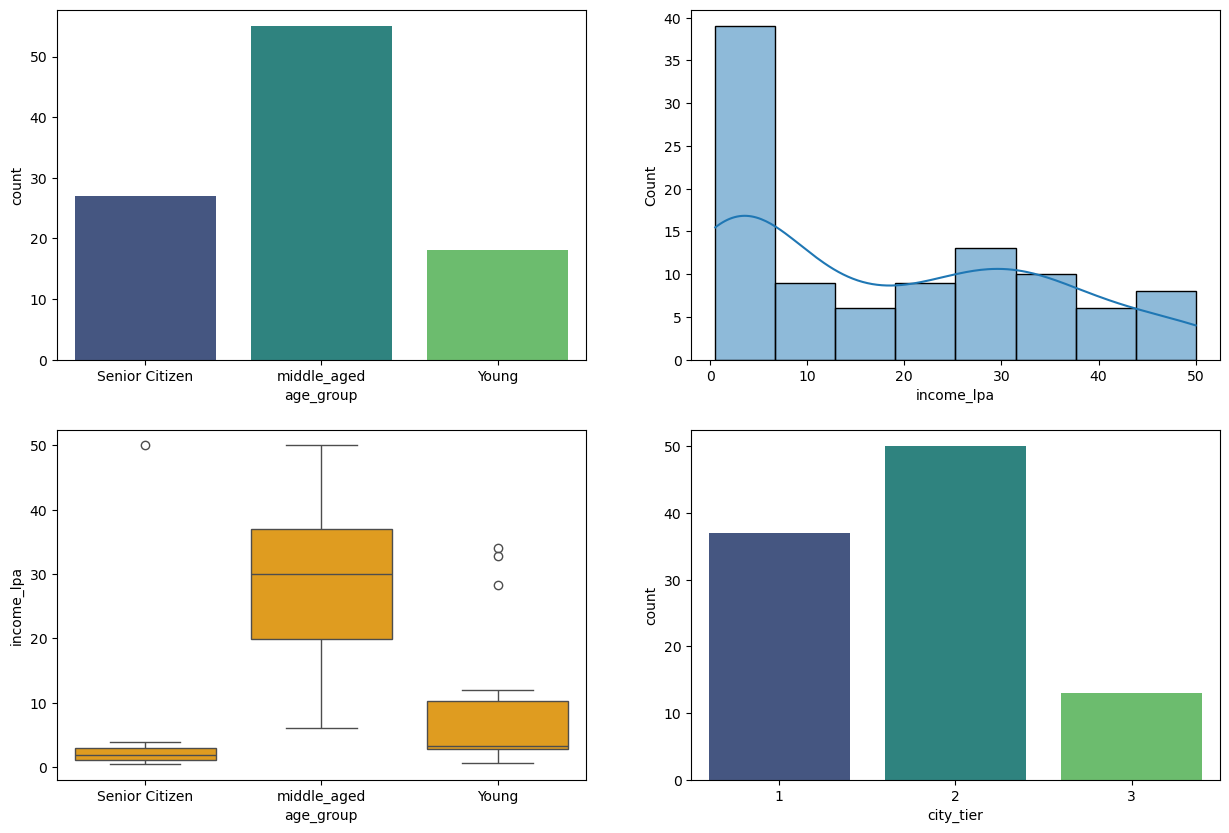

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
fig,ax=plt.subplots(2,2,figsize=(15,10))
sns.countplot(x=df['age_group'],data=df,ax=ax[0,0], palette='viridis',hue='age_group')
sns.histplot(x=df['income_lpa'],data=df,kde=True,ax=ax[0,1])
sns.boxplot( x='age_group',y='income_lpa',data=df,color='orange',ax=ax[1,0])
sns.countplot(x=df['city_tier'], palette='viridis')

Key Insights:

1)Most of the people are middle-aged (above 30 and below 60)

2)The annual income mostly lies between 0-10 lpa

3)Only one senior citizen is earning around 50 lpa and 3 young people earning around 30-40 lpa

4)Most of the people are from Tier-2 cities





There are 4 categorical columns ,in which 3 are input and 1 is output

We need to convert 3 into numerics using the OneHotEncoding

In [15]:
X=df.drop(columns=['insurance_premium_category'])
y=df['insurance_premium_category']

In [16]:
cat_cols=['age_group','lifestyle_risk','occupation','city_tier']
num_cols=['bmi','income_lpa']
ct=ColumnTransformer(
    transformers=[
    ('cat',OneHotEncoder(),cat_cols),
    ('num','passthrough',num_cols)
])
model=Pipeline([
('ColumnTransformer',ct),
('model',LogisticRegression())
])

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [18]:
model.fit(X_train,y_train)

d:\Datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('ColumnTransformer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [19]:
y_pred=model.predict(X_test)
print("accuracy_score is :",accuracy_score(y_test,y_pred))
print("\nclassification_report:\n",classification_report(y_test,y_pred))
print("\nConfusion matrix :\n",confusion_matrix(y_test,y_pred))

accuracy_score is : 0.9

classification_report:
               precision    recall  f1-score   support

        High       0.88      1.00      0.93         7
         Low       0.80      1.00      0.89         4
      Medium       1.00      0.78      0.88         9

    accuracy                           0.90        20
   macro avg       0.89      0.93      0.90        20
weighted avg       0.92      0.90      0.90        20


Confusion matrix :
 [[7 0 0]
 [0 4 0]
 [1 1 7]]


In [21]:
import pickle
with open('model.pkl','wb') as f:
    pickle.dump(model,f)

Model is saved as pickle file